In [225]:
from functions import *
from firedrake import *
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection #need for quad mesh
import gmsh #unstructed mesh
from firedrake.pyplot import triplot #plotting the mesh
import pandas as pd
import logging
opts = {
    "eps_gen_non_hermitian": None,
    "eps_target": 0.95,              # off 1.0, which is a genuine eigenvalue
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500,
}      

In [226]:
def make_crisscross_Lshape_mesh(n_cells_per_unit=10):
    """
    Builds a structured 'criss-cross' L-shaped mesh using Gmsh.
    
    Parameters:
    n_cells_per_unit (int): Number of edges along a 1x1 length.
    """
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0) # Suppress Gmsh console output
    gmsh.model.add("L_shape_structured")
    
    # 1. Define the corner points of the L-shape and the inner junction
    p1 = gmsh.model.geo.addPoint(0, 0, 0)
    p2 = gmsh.model.geo.addPoint(1, 0, 0)
    p3 = gmsh.model.geo.addPoint(2, 0, 0)
    p4 = gmsh.model.geo.addPoint(2, 1, 0)
    p5 = gmsh.model.geo.addPoint(1, 1, 0) # Inner corner
    p6 = gmsh.model.geo.addPoint(1, 2, 0)
    p7 = gmsh.model.geo.addPoint(0, 2, 0)
    p8 = gmsh.model.geo.addPoint(0, 1, 0) # Inner junction left
    
    # 2. Define the outer boundary lines
    l1 = gmsh.model.geo.addLine(p1, p2) # Bottom left
    l2 = gmsh.model.geo.addLine(p2, p3) # Bottom right
    l3 = gmsh.model.geo.addLine(p3, p4) # Right edge
    l4 = gmsh.model.geo.addLine(p4, p5) # Inner horizontal
    l5 = gmsh.model.geo.addLine(p5, p6) # Inner vertical
    l6 = gmsh.model.geo.addLine(p6, p7) # Top edge
    l7 = gmsh.model.geo.addLine(p7, p8) # Top left outer
    l8 = gmsh.model.geo.addLine(p8, p1) # Bottom left outer
    
    # 3. Define internal lines to split the L into 3 distinct squares
    l_int1 = gmsh.model.geo.addLine(p2, p5) # Splits bottom-left from bottom-right
    l_int2 = gmsh.model.geo.addLine(p8, p5) # Splits bottom-left from top-left
    
    # 4. Define the 3 squares (Curve Loops and Plane Surfaces)
    cl1 = gmsh.model.geo.addCurveLoop([l1, l_int1, -l_int2, l8])
    s1 = gmsh.model.geo.addPlaneSurface([cl1])  # Bottom-Left Square
    
    cl2 = gmsh.model.geo.addCurveLoop([l2, l3, l4, -l_int1])
    s2 = gmsh.model.geo.addPlaneSurface([cl2])  # Bottom-Right Square
    
    cl3 = gmsh.model.geo.addCurveLoop([l_int2, l5, l6, l7])
    s3 = gmsh.model.geo.addPlaneSurface([cl3])  # Top-Left Square
    
    gmsh.model.geo.synchronize()
    
    # 5. Enforce a Structured (Transfinite) Grid
    # Assign the number of nodes per line (cells + 1)
    for line in [l1, l2, l3, l4, l5, l6, l7, l8, l_int1, l_int2]:
        gmsh.model.mesh.setTransfiniteCurve(line, n_cells_per_unit + 1)
        
    # Set surfaces to be structured. 
    # arrangement="Alternate" is the Gmsh command for a criss-cross mesh!
    # (You can also use "Left" or "Right" for diagonal lines leaning one way).
    for surface in [s1, s2, s3]:
        gmsh.model.mesh.setTransfiniteSurface(surface, arrangement="Alternate")
    
    # 6. Generate the mesh
    gmsh.model.mesh.generate(2)
    
    # 7. Safely pass it into Firedrake via a temporary .msh file
    with tempfile.TemporaryDirectory() as tmpdir:
        msh_file = os.path.join(tmpdir, "structured_lshape.msh")
        gmsh.write(msh_file)
        mesh = Mesh(msh_file)
        
    gmsh.finalize()
    
    return mesh
    
def plot_eigenmode(solver, index, title_prefix=""):
    """
    Extracts and plots the vector field and magnitude of a specific eigenmode.
    """
    # 1. Extract the complex eigenvalue and get its real part
    eval_c = solver.eigenvalue(index)
    lr = np.real(eval_c)
    
    # 2. Extract the real eigenfunction
    vr, vi = solver.eigenfunction(index)
    
    # vr is the real part of the eigenfunction, living in your mixed space (V * Q)
    v_field = vr.subfunctions[0]
    
    # =================================================================
    # FIX 1: Project the Nédélec field to a standard CG vector space 
    # so the plotting backend can calculate the magnitude without crashing.
    # =================================================================
    mesh = v_field.function_space().mesh()
    V_plot = VectorFunctionSpace(mesh, "CG", 1)
    v_plot = project(v_field, V_plot)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # =================================================================
    # FIX 2: Safely combine f-strings and raw strings for the LaTeX math
    # =================================================================
    title_str = f"{title_prefix} Mode {index} - Vector Field\n" + r"$\lambda \approx$ " + f"{lr:.4f}"
    
    # 3. Plot the Vector Field (Arrows) using the projected field
    quiver(v_plot, axes=ax1)
    ax1.set_title(title_str)
    ax1.set_aspect('equal')
    
    # 4. Plot the Magnitude (Heatmap) using the projected field
    contour = tripcolor(v_plot, axes=ax2, cmap='inferno')
    fig.colorbar(contour, ax=ax2)
    ax2.set_title(f"{title_prefix} Mode {index} - Magnitude")
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

## Fixed Criss-Cross mesh, L shape

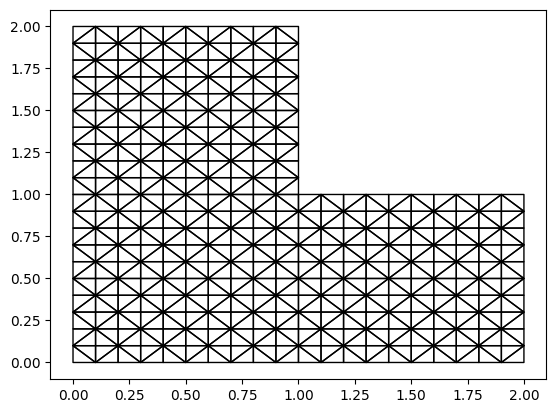

In [229]:
import os, tempfile
mesh = make_crisscross_Lshape_mesh(n_cells_per_unit=10)
triplot(mesh)

In [ ]:
base_mesh = make_Lshape_mesh(maxh=0.5)

# 2. Create the Mesh Hierarchy
# 'refinement_levels' determines how many times the base mesh is uniformly refined.
# If levels=3, you get a hierarchy of 4 meshes (base + 3 refinements).
hierarchy = MeshHierarchy(base_mesh, refinement_levels=3)